In [4]:
import pandas as pd
import plotly.express as px

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [5]:
print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

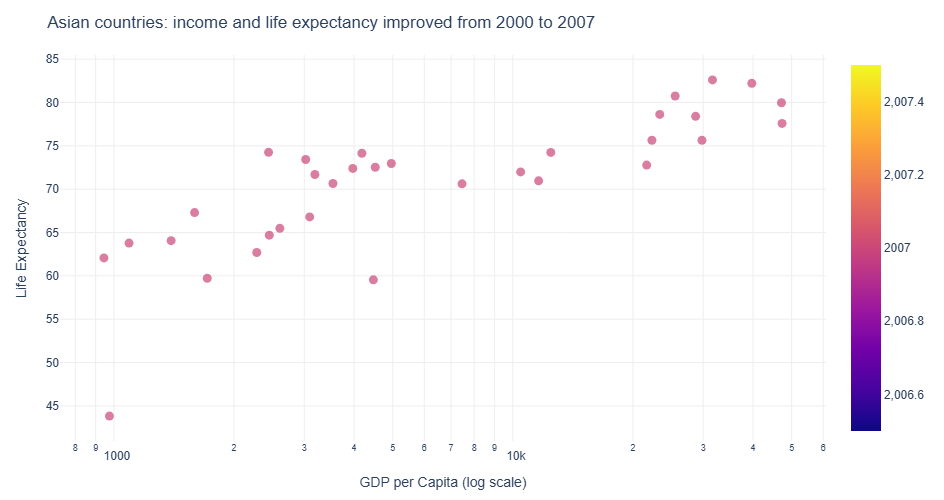

In [6]:

df_task1 = df.loc[
    (df['continent'] == 'Asia') &
    (df['year'].isin([2000, 2007]))
]

fig = px.scatter(
    data_frame=df_task1,
    x='gdpPercap',
    y='lifeExp',
    color='year',  
    hover_name='country',
    log_x=True,
    labels={
        'gdpPercap': 'GDP per Capita (log scale)',
        'lifeExp': 'Life Expectancy',
        'year': ''
    },
    title='Asian countries: income and life expectancy improved from 2000 to 2007'
)

fig.update_traces(marker=dict(size=9, opacity=0.7))

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(gridcolor='#EEEEEE'),
    yaxis=dict(gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40),
    height=500
)

fig.show()


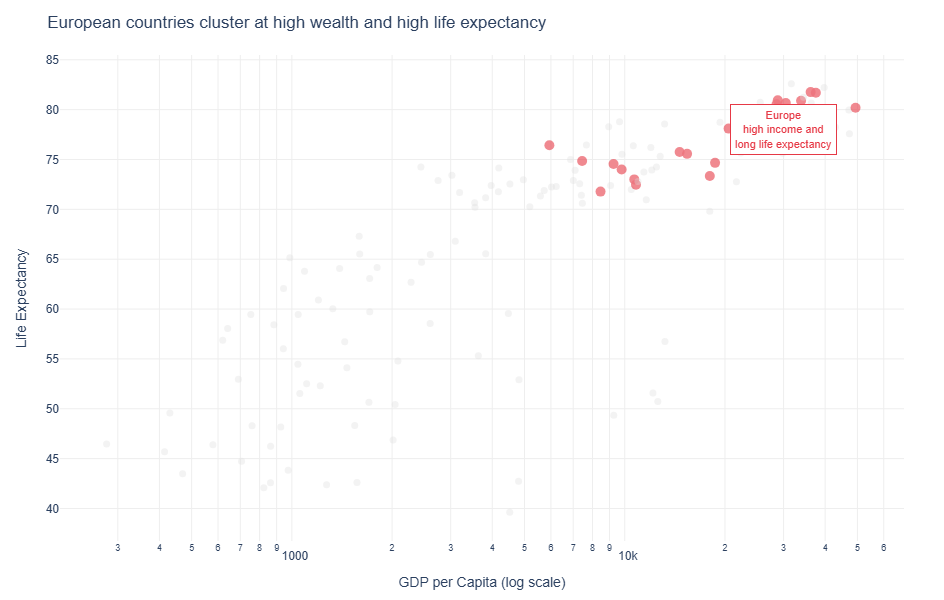

In [7]:
highlight_continent = 'Europe'

colour_map = {
    c: ('#E63946' if c == highlight_continent else '#DDDDDD')
    for c in df['continent'].unique()
}

df_2007 = df[df['year'] == 2007]

fig = px.scatter(
    data_frame=df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='continent',
    color_discrete_map=colour_map,
    hover_name='country',
    log_x=True,
    size_max=60,
    labels={
        'gdpPercap': 'GDP per Capita (log scale)',
        'lifeExp': 'Life Expectancy',
        'pop': 'Population',
        'continent': ''
    },
    title='European countries cluster at high wealth and high life expectancy'
)

fig.update_traces(
    showlegend=False,
    opacity=0.7
)

# highlight style
fig.update_traces(
    selector=dict(name=highlight_continent),
    marker=dict(size=10, opacity=0.85)
)

fig.update_traces(
    selector=lambda t: t.name != highlight_continent,
    marker=dict(size=7, opacity=0.5)
)

# annotation (VERY IMPORTANT — don’t skip)
import math

fig.add_annotation(
    x=math.log10(30000),
    y=78,
    text='Europe<br>high income and<br>long life expectancy',
    showarrow=False,
    font=dict(color='#E63946', size=11, family='Arial'),
    bgcolor='white',
    bordercolor='#E63946',
    borderwidth=1,
    borderpad=4
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(gridcolor='#EEEEEE'),
    yaxis=dict(gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40),
    height=600
)

fig.show()
 